# PosRecoCVN Training

Position and direction reconstruction training pipeline for the SBND detector.
Uses a reduced ResNet-18 architecture (~3M parameters) to predict neutrino vertex
position (X, Y, Z) and direction (dirY, dirZ) from PMT light images.


## 1. Setup and Configuration

In [1]:
# Suppress TensorFlow warnings and info messages
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress INFO and WARNING messages
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # Only if you want to specify GPU

# Essential imports only
import sys
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

# TensorFlow with GPU memory growth
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

#  Configure GPU memory growth for JupyterHub
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
   tf.config.experimental.set_memory_growth(gpus[0], True)
   print(">> GPU configured with memory growth for JupyterHub")
   print(f"   * Available GPU: {gpus[0]}")
  except RuntimeError as e:
   print(f"! GPU configuration warning: {e}")
else:
  print("! No GPU found")

# Auto-detect training directory based on project structure
def find_training_directory():
  """Find the training directory automatically based on project structure."""

  # Method 1: Check if we're already in the training directory
  if os.path.exists('config.py') and os.path.exists('utils.py'):
   return os.getcwd()

  # Method 2: Look for sbndcode structure from common paths
  possible_bases = [
   # Standard LArSoft development paths
   "/exp/sbnd/app/users/{}/larsoft_*/srcs/sbndcode",
   "/exp/sbnd/app/users/{}/*/srcs/sbndcode",
   # Alternative paths
   "/home/{}/sbndcode",
   "/home/{}/larsoft_*/srcs/sbndcode",
   # Current directory relatives
   "./sbndcode",
   "../sbndcode",
   "../../sbndcode",
  ]

  # Get current user
  import getpass
  username = getpass.getuser()

  # Expand paths with username and wildcards
  import glob
  expanded_paths = []
  for base in possible_bases:
   if '{}' in base:
    base = base.format(username)
   if '*' in base:
    expanded_paths.extend(glob.glob(base))
   else:
    expanded_paths.append(base)

  # Check each potential sbndcode directory
  for sbndcode_path in expanded_paths:
   training_path = os.path.join(sbndcode_path, "sbndcode", "PosRecoCVN", "training")
   if os.path.exists(training_path) and os.path.exists(os.path.join(training_path, "config.py")):
    return training_path

  # Method 3: Search upwards from current directory
  current = os.getcwd()
  for _ in range(5):  # Don't go too far up
   training_path = os.path.join(current, "sbndcode", "PosRecoCVN", "training")
   if os.path.exists(training_path) and os.path.exists(os.path.join(training_path, "config.py")):
    return training_path
   parent = os.path.dirname(current)
   if parent == current:  # reached root
    break
   current = parent

  return None

# Find and set training directory
print(">> Auto-detecting training directory...")
training_dir = find_training_directory()

if training_dir:
  print(f">> Found training directory: {training_dir}")
  if os.getcwd() != training_dir:
   print(f"   * Changing directory from {os.getcwd()} to {training_dir}")
   os.chdir(training_dir)
else:
  print("! Could not find training directory automatically")
  print("* Manual setup options:")
  print("  1. Navigate to your training directory:")
  print("     os.chdir('/path/to/your/sbndcode/sbndcode/PosRecoCVN/training')")
  print("  2. Or copy the required files:")
  print("     !cp /path/to/your/training/config.py .")
  print("     !cp /path/to/your/training/utils.py .")
  print("  3. Or add your training directory to Python path:")
  print("     sys.path.append('/path/to/your/training/directory')")

# Add current directory to Python path
if os.getcwd() not in sys.path:
  sys.path.append(os.getcwd())

# Debug info
print(f"\n* Current working directory: {os.getcwd()}")
print(f"* config.py exists: {os.path.exists('config.py')}")
print(f"* utils.py exists: {os.path.exists('utils.py')}")

# Try to import local modules
config_imported = False
utils_imported = False

try:
  from config import *
  config_imported = True
  print(">> config module imported successfully")
except ImportError as e:
  print(f"! config import error: {e}")

try:
  from utils import *
  utils_imported = True
  print(">> utils module imported successfully")
except ImportError as e:
  print(f"! utils import error: {e}")

if not (config_imported and utils_imported):
  print("\n* If auto-detection failed, try one of these solutions:")
  print("  1. Manual directory change:")
  print("     os.chdir('/exp/sbnd/app/users/YOUR_USERNAME/larsoft_*/srcs/sbndcode/sbndcode/PosRecoCVN/training')")
  print("  2. Add to Python path:")
  print("     sys.path.append('/path/to/your/training/directory')")
  print("  3. Copy files to current directory")
  print("\n   Then restart this cell.")

# Only run these if modules were imported successfully
if config_imported and utils_imported:
  print(" ============================================")
  print("   PosRecoCNN Training Pipeline - GPU Mode")
  print(" ============================================")
  print_config_summary()
  validate_paths()
else:
  print("! Skipping configuration check until modules are properly imported")

2026-02-23 23:27:57.544469: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-23 23:27:57.544570: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-23 23:27:57.545763: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


>> GPU configured with memory growth for JupyterHub
   * Available GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
>> Auto-detecting training directory...
>> Found training directory: /exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCVN/training
   * Changing directory from /home/svidales to /exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCVN/training

* Current working directory: /exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCVN/training
* config.py exists: True
* utils.py exists: True
>> config module imported successfully
>> utils module imported successfully
   PosRecoCNN Training Pipeline - GPU Mode
Dual TPC CNN Flash Matcher
Input: 4 channels (TPC0_uncoated, TPC0_coated, TPC1_uncoated, TPC1_coated)
Output: 14 values (7 per TPC: pos + dir + conf)
Training: 50 epochs, batch=32
ERROR: Missing coated map: /exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCV

## 2. Preprocessing using .py tool

In [40]:
# Ejecutar preprocesamiento DIRECTAMENTE en el notebook
import os
import sys
BACKUP_DIR = '/exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCVN/training'

# Limpiar sys.path
parent_dir = os.path.dirname(BACKUP_DIR)
if parent_dir in sys.path:
    sys.path.remove(parent_dir)

if BACKUP_DIR in sys.path:
    sys.path.remove(BACKUP_DIR)
sys.path.insert(0, BACKUP_DIR)

os.chdir(BACKUP_DIR)

print(f"✓ Directorio: {os.getcwd()}")
print(f"✓ PMT maps existe: {os.path.exists('pmt_maps')}")

# Recargar módulos
import importlib
for mod in ['config', 'utils', 'preprocess_images']:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

import preprocess_images
sys.argv = [
    'preprocess_images.py',
    '-i', '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/fall_training_test_MC_withPCA/test/test_fall_prod_v0902_withPCA_part02.root',
    '-o', '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/preprocessed_images/resnet18_onetpc_withPCA/test',
    '-v',
]

preprocess_images.main()


✓ Directorio: /exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/PosRecoCVN/training
✓ PMT maps existe: True
  PosRecoCVN Image Preprocessor
Input:      /exp/sbnd/data/users/svidales/AI_nuvT_project_support/fall_training_test_MC_withPCA/test/test_fall_prod_v0902_withPCA_part02.root
Output:     /exp/sbnd/data/users/svidales/AI_nuvT_project_support/preprocessed_images/resnet18_onetpc_withPCA/test
>> File too large to copy (104.7 GB > 10.0 GB)
   * Reading directly from network storage
>> Loading ROOT file: test_fall_prod_v0902_withPCA_part02.root
   * Total events in file: 68,514
   * File size: 104.7 GB
   * Loading 17 arrays with 16 threads...
   * This may take several minutes for large files on network storage...
>> Data loaded in 86.4 seconds
   * Channel dictionary: 312 channels

>> Applying filters...
>> Starting optimized event processing...
Initial events: 68,514
Applying active volume filter...
Processing flashes...
Applying data validity cuts...
Applying energ

,Cut,Removed,Remaining,Cumulative_Eff
0,Neutrinos in active volume + single neutrino,38192,30322,0.443
1,Has flashes,3497,26825,0.392
2,Valid data (≠ -999 in dEprom),64,26761,0.391
3,Energy cut,1801,24960,0.364
4,dEprom in active volume cut,4,24956,0.364


Final efficiency: 0.364 (24,956/68,514)

* Final dataset ranges:
  dEpromx: [-200.0, 199.9]
  dEpromy: [-199.0, 199.3]
  dEpromz: [4.1, 499.7]
  dEtpc: [50.0, 5680.0]

>> Events after filtering: 24,956

>> Creating PE matrix...
Creating PE matrix for 24,956 events x 312 channels [numba (parallel)]
>> Completed in 1.65 seconds
   Matrix shape: (24956, 312)
   Non-zero elements: 1,674,734
   Total PE: 373120096.0

>> Loading PMT maps...
   * Uncoated map shape: (118, 70)
   * Coated map shape: (118, 70)

>> Creating PE images (raw, unnormalized)...
Creating 24,956 images (59×70×2)
>> Images created: (24956, 59, 70, 2)
   * Max PE values (for later normalization): [71784.51]

>> Saving 24,956 events...
   * Saved: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/preprocessed_images/resnet18_onetpc_withPCA/test/test_fall_prod_v0902_withPCA_part02.npz (24,956 events, 9.2 MB)
>> Saved preprocessing info: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/preprocessed_images/resnet18_

## 3. Importing images and variables preprocessed

In [2]:
# Load preprocessed NPZ files and combine
import glob

preprocessed_dir = '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/preprocessed_images/resnet18_onetpc_withPCA/training'

# Find all part files
npz_files = sorted(glob.glob(os.path.join(preprocessed_dir, 'training_fall_prod_v0902_withPCA_part*.npz')))
print(f">> Found {len(npz_files)} preprocessed files:")
for f in npz_files:
    print(f"   * {os.path.basename(f)}")

# Load and combine all files
all_images = []
all_x_abs = []
all_y = []
all_z = []
all_dirx = []
all_diry = []
all_dirz = []
all_spreadx = []
all_spready = []
all_spreadz = []
all_max_pe = []

for npz_file in npz_files:
    print(f"\n>> Loading {os.path.basename(npz_file)}...")
    data = np.load(npz_file)
    
    all_images.append(data['images'])
    all_x_abs.append(data['dEpromx_abs'])
    all_y.append(data['dEpromy'])
    all_z.append(data['dEpromz'])
    
    # PCA direction variables
    all_dirx.append(data['dEdirx'])
    all_diry.append(data['dEdiry'])
    all_dirz.append(data['dEdirz'])
    
    # PCA spread variables
    all_spreadx.append(data['dEspreadx'])
    all_spready.append(data['dEspready'])
    all_spreadz.append(data['dEspreadz'])
    
    # Max PE values
    all_max_pe.append(data['max_pe_values'][0])
    
    print(f"   * Events: {len(data['images']):,}")
    print(f"   * Max PE value: {data['max_pe_values'][0]:.1f}")

# Combine all data
print("\n>> Combining all files...")
images_raw = np.concatenate(all_images, axis=0)
x_abs = np.concatenate(all_x_abs, axis=0)
y = np.concatenate(all_y, axis=0)
z = np.concatenate(all_z, axis=0)

# PCA variables
dEdirx = np.concatenate(all_dirx, axis=0)
dEdiry = np.concatenate(all_diry, axis=0)
dEdirz = np.concatenate(all_dirz, axis=0)

# ========================================================================
# FIX SIGN: Force directions to point toward +Z (beam direction)
# ========================================================================
print("\n>> Fixing PCA direction signs to point toward +Z (beam direction)...")

# Check how many directions point toward -Z
negative_z_mask = dEdirz < 0
n_negative = np.sum(negative_z_mask)
print(f"   * Directions pointing toward -Z: {n_negative:,} ({100*n_negative/len(dEdirz):.1f}%)")

# Flip directions that point toward -Z
dEdirx[negative_z_mask] = -dEdirx[negative_z_mask]
dEdiry[negative_z_mask] = -dEdiry[negative_z_mask]
dEdirz[negative_z_mask] = -dEdirz[negative_z_mask]

print(f"   * All directions now point toward +Z")
print(f"   * New dirz range: [{np.nanmin(dEdirz):.3f}, {np.nanmax(dEdirz):.3f}]")


dEspreadx = np.concatenate(all_spreadx, axis=0)
dEspready = np.concatenate(all_spready, axis=0)
dEspreadz = np.concatenate(all_spreadz, axis=0)

# Normalize GLOBALLY (all images divided by global max across ALL files)
print(f"\n>> Normalizing images globally...")

# Calculate GLOBAL max across ALL events from all files
global_max = max(all_max_pe)  # Use the maximum of max_pe_values from all files
print(f"   * Global max value (from max_pe_values): {global_max:.1f}")
print(f"   * Actual max in images: {np.max(images_raw):.1f}")

# Normalize all images by the global max
images = images_raw / global_max

# Save global factor for inference
normalization_factor = global_max

# Summary
print(f"\n>> Data loaded and normalized (global):")
print(f"   * Total events: {len(images):,}")
print(f"   * Images shape: {images.shape}")
print(f"   * Images range: [{images.min():.6f}, {images.max():.6f}]")
print(f"   * Normalization factor: {normalization_factor:.1f}")
print()
print(f">> Baricentro (dEprom):")
print(f"   * X range: [{x_abs.min():.1f}, {x_abs.max():.1f}] cm")
print(f"   * Y range: [{y.min():.1f}, {y.max():.1f}] cm")
print(f"   * Z range: [{z.min():.1f}, {z.max():.1f}] cm")
print()
print(f">> PCA Direction (dEdir):")
print(f"   * dirx range: [{np.nanmin(dEdirx):.4f}, {np.nanmax(dEdirx):.4f}]")
print(f"   * diry range: [{np.nanmin(dEdiry):.4f}, {np.nanmax(dEdiry):.4f}]")
print(f"   * dirz range: [{np.nanmin(dEdirz):.4f}, {np.nanmax(dEdirz):.4f}]")
print()
print(f">> PCA Spread (dEspread):")
print(f"   * spreadx range: [{np.nanmin(dEspreadx):.1f}, {np.nanmax(dEspreadx):.1f}] cm")
print(f"   * spready range: [{np.nanmin(dEspready):.1f}, {np.nanmax(dEspready):.1f}] cm")
print(f"   * spreadz range: [{np.nanmin(dEspreadz):.1f}, {np.nanmax(dEspreadz):.1f}] cm")

# Create dEprom variables for compatibility with next cells
dEpromx_final = x_abs
dEpromy_final = y
dEpromz_final = z

# Clean up raw images to save memory
del images_raw, all_images, all_x_abs, all_y, all_z
del all_dirx, all_diry, all_dirz
del all_spreadx, all_spready, all_spreadz
del all_max_pe
import gc
gc.collect()
print("\n>> Memory cleaned up")

>> Found 7 preprocessed files:
   * training_fall_prod_v0902_withPCA_part01.npz
   * training_fall_prod_v0902_withPCA_part02.npz
   * training_fall_prod_v0902_withPCA_part03.npz
   * training_fall_prod_v0902_withPCA_part04.npz
   * training_fall_prod_v0902_withPCA_part05.npz
   * training_fall_prod_v0902_withPCA_part06.npz
   * training_fall_prod_v0902_withPCA_part07.npz

>> Loading training_fall_prod_v0902_withPCA_part01.npz...
   * Events: 27,779
   * Max PE value: 155478.8

>> Loading training_fall_prod_v0902_withPCA_part02.npz...
   * Events: 28,308
   * Max PE value: 121025.3

>> Loading training_fall_prod_v0902_withPCA_part03.npz...
   * Events: 28,673
   * Max PE value: 102726.4

>> Loading training_fall_prod_v0902_withPCA_part04.npz...
   * Events: 28,256
   * Max PE value: 189310.8

>> Loading training_fall_prod_v0902_withPCA_part05.npz...
   * Events: 28,215
   * Max PE value: 123270.3

>> Loading training_fall_prod_v0902_withPCA_part06.npz...
   * Events: 28,243
   * Max PE 

**Example of an image normalized**

>> Example event #83209
   * Position: X=31.8 cm, Y=81.4 cm, Z=409.1 cm


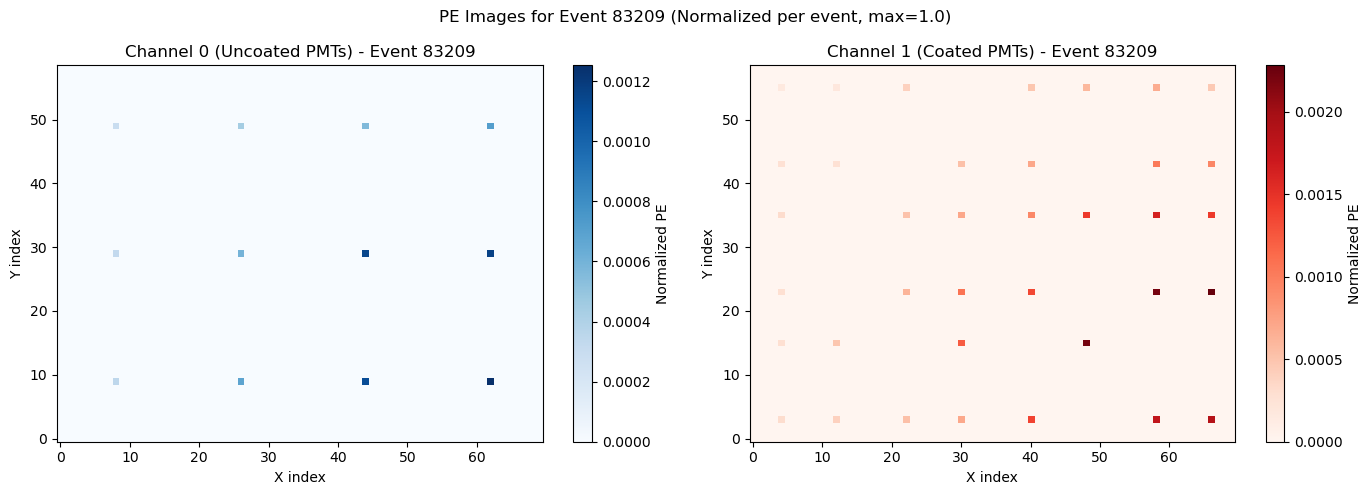


>> Image statistics:
   * Shape: (59, 70, 2)
   * Channel 0 (Uncoated): min=0.0000, max=0.0013, mean=0.0000
   * Channel 1 (Coated):   min=0.0000, max=0.0023, mean=0.0000
   * Non-zero pixels: 49 / 8260 (0.6%)


In [3]:
# Visualize example PE images for a random event
import matplotlib.pyplot as plt

# Pick a random event
np.random.seed(10)
event_idx = np.random.randint(0, len(images))

print(f">> Example event #{event_idx}")
print(f"   * Position: X={dEpromx_final[event_idx]:.1f} cm, Y={dEpromy_final[event_idx]:.1f} cm, Z={dEpromz_final[event_idx]:.1f} cm")

# Get the image for this event
img = images[event_idx]  # Shape: (59, 70, 2)

# Create figure with 2 subplots (one per channel)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Channel 0: Uncoated PMTs
im0 = axes[0].imshow(img[:, :, 0], cmap='Blues', aspect='auto', origin='lower')
axes[0].set_title(f'Channel 0 (Uncoated PMTs) - Event {event_idx}')
axes[0].set_xlabel('X index')
axes[0].set_ylabel('Y index')
plt.colorbar(im0, ax=axes[0], label='Normalized PE')

# Channel 1: Coated PMTs
im1 = axes[1].imshow(img[:, :, 1], cmap='Reds', aspect='auto', origin='lower')
axes[1].set_title(f'Channel 1 (Coated PMTs) - Event {event_idx}')
axes[1].set_xlabel('X index')
axes[1].set_ylabel('Y index')
plt.colorbar(im1, ax=axes[1], label='Normalized PE')

plt.suptitle(f'PE Images for Event {event_idx} (Normalized per event, max=1.0)', fontsize=12)
plt.tight_layout()
plt.show()

# Print image statistics
print(f"\n>> Image statistics:")
print(f"   * Shape: {img.shape}")
print(f"   * Channel 0 (Uncoated): min={img[:,:,0].min():.4f}, max={img[:,:,0].max():.4f}, mean={img[:,:,0].mean():.4f}")
print(f"   * Channel 1 (Coated):   min={img[:,:,1].min():.4f}, max={img[:,:,1].max():.4f}, mean={img[:,:,1].mean():.4f}")
print(f"   * Non-zero pixels: {np.count_nonzero(img)} / {img.size} ({100*np.count_nonzero(img)/img.size:.1f}%)")

## 4. Target Variable Preparation

In [3]:
# Prepare coordinates (use absolute x)
print(">> Preparing target variables...")

# Baricentro (dEprom)
x_abs = np.abs(np.array(dEpromx_final).flatten())
y = np.array(dEpromy_final).flatten()
z = np.array(dEpromz_final).flatten()

coordinates = np.column_stack((x_abs, y, z))
print(f"   * Coordinate ranges before scaling:")
print(f"     - X (abs): [{np.min(x_abs):.1f}, {np.max(x_abs):.1f}]")
print(f"     - Y: [{np.min(y):.1f}, {np.max(y):.1f}]")
print(f"     - Z: [{np.min(z):.1f}, {np.max(z):.1f}]")

# Scale coordinates using config
y_scaled = scale_coordinates(coordinates, COORD_CONFIG['scale_ranges'])
print(f"\n   * Scaled coordinate ranges:")
print(f"     - X: [{np.min(y_scaled[:, 0]):.3f}, {np.max(y_scaled[:, 0]):.3f}]")
print(f"     - Y: [{np.min(y_scaled[:, 1]):.3f}, {np.max(y_scaled[:, 1]):.3f}]")
print(f"     - Z: [{np.min(y_scaled[:, 2]):.3f}, {np.max(y_scaled[:, 2]):.3f}]")

# ========================================================================
# TARGET 1: Position (y_pos) - shape (N, 3)
# ========================================================================
y_pos = y_scaled  # (N, 3)
print(f"\n   * Position target shape: {y_pos.shape}")

# ========================================================================
# TARGET 2: Direction 2D in YZ plane (y_dir) - shape (N, 2)
# ========================================================================
dirx = np.array(dEdirx).flatten()
diry = np.array(dEdiry).flatten()
dirz = np.array(dEdirz).flatten()

print(f"\n   * PCA Direction 3D ranges:")
print(f"     - dirx: [{np.nanmin(dirx):.3f}, {np.nanmax(dirx):.3f}]")
print(f"     - diry: [{np.nanmin(diry):.3f}, {np.nanmax(diry):.3f}]")
print(f"     - dirz: [{np.nanmin(dirz):.3f}, {np.nanmax(dirz):.3f}]")

# Project onto YZ plane and normalize
norm_yz = np.sqrt(diry**2 + dirz**2)
norm_yz_safe = np.maximum(norm_yz, 1e-6)
dir2d_y = diry / norm_yz_safe
dir2d_z = dirz / norm_yz_safe

y_dir = np.column_stack((dir2d_y, dir2d_z))  # (N, 2)

print(f"\n   * Direction 2D target (YZ plane):")
print(f"     - dir2d_y: [{np.min(dir2d_y):.3f}, {np.max(dir2d_y):.3f}]")
print(f"     - dir2d_z: [{np.min(dir2d_z):.3f}, {np.max(dir2d_z):.3f}]")

# Check for invalid values
invalid_mask = (dirx == -999) | (diry == -999) | (dirz == -999) | \
               np.isnan(dirx) | np.isnan(diry) | np.isnan(dirz)
n_invalid = np.sum(invalid_mask)
if n_invalid > 0:
    print(f"\n   WARNING: {n_invalid} events have invalid PCA direction values")

# Check for near-degenerate YZ projections
n_degenerate = np.sum(norm_yz < 0.1)
print(f"\n   * Events with norm_yz < 0.1 (nearly along X): {n_degenerate} ({100*np.mean(norm_yz < 0.1):.2f}%)")

# Filter out invalid and degenerate events
good_mask = ~invalid_mask & (norm_yz >= 0.1)
n_removed = np.sum(~good_mask)
if n_removed > 0:
    print(f"\n   * Filtering {n_removed} invalid/degenerate events...")
    y_pos = y_pos[good_mask]
    y_dir = y_dir[good_mask]
    images = images[good_mask]
    print(f"   * Remaining events: {len(y_pos):,}")

# ========================================================================
# WEIGHT: Directionality from dEspread (elongation metric)
# Higher weight = more track-like event = PCA direction more reliable
# ========================================================================
spreadx = np.array(dEspreadx).flatten()
spready = np.array(dEspready).flatten()
spreadz = np.array(dEspreadz).flatten()

# Apply same good_mask as other arrays
if n_removed > 0:
    spreadx = spreadx[good_mask]
    spready = spready[good_mask]
    spreadz = spreadz[good_mask]

lambda_sum = spreadx + spready + spreadz + 1e-6
lambda_max = np.maximum(np.maximum(spreadx, spready), spreadz)
w_dir = lambda_max / lambda_sum  # range [1/3 (isotropic) to 1 (perfect track)]

# Normalize so mean weight = 1 (preserves overall loss scale)
w_dir = w_dir / (np.mean(w_dir) + 1e-8)

print(f"\n   * Directionality weights from dEspread:")
print(f"     - Range: [{np.min(w_dir):.3f}, {np.max(w_dir):.3f}]")
print(f"     - Mean: {np.mean(w_dir):.3f} (normalized to 1.0)")
print(f"     - Events with w > 1.5 (track-like): {100*np.mean(w_dir > 1.5):.1f}%")

# ========================================================================
# Combined target for train/val split (will be separated after split)
# y_combined = [pos(3), dir2d(2), w_dir(1)] = 6 columns
# ========================================================================
y_combined = np.column_stack((y_pos, y_dir, w_dir.reshape(-1, 1)))
print(f"\n   * Combined target shape: {y_combined.shape}")
print(f"     - Position (scaled): columns 0-2")
print(f"     - Direction 2D (YZ): columns 3-4")
print(f"     - Direction weight (dEspread): column 5")
print(f"\n>> Two separate models will be trained:")
print(f"   * Model 1: Position (ResNet-18, MSE loss) - original config")
print(f"   * Model 2: Direction 2D YZ (ResNet-18, sign-invariant angular loss)")

>> Preparing target variables...
   * Coordinate ranges before scaling:
     - X (abs): [0.6, 200.0]
     - Y: [-199.4, 199.3]
     - Z: [2.4, 499.9]

   * Scaled coordinate ranges:
     - X: [0.003, 1.000]
     - Y: [-0.997, 0.996]
     - Z: [0.005, 1.000]

   * Position target shape: (197634, 3)

   * PCA Direction 3D ranges:
     - dirx: [-1.000, 1.000]
     - diry: [-1.000, 1.000]
     - dirz: [0.000, 1.000]

   * Direction 2D target (YZ plane):
     - dir2d_y: [-1.000, 1.000]
     - dir2d_z: [0.000, 1.000]

   * Events with norm_yz < 0.1 (nearly along X): 481 (0.24%)

   * Filtering 481 invalid/degenerate events...
   * Remaining events: 197,153

   * Directionality weights from dEspread:
     - Range: [0.666, 1.935]
     - Mean: 1.000 (normalized to 1.0)
     - Events with w > 1.5 (track-like): 2.9%

   * Combined target shape: (197153, 6)
     - Position (scaled): columns 0-2
     - Direction 2D (YZ): columns 3-4
     - Direction weight (dEspread): column 5

>> Two separate mode

## 5. Train/Validation Split

In [4]:
# Calculate split sizes (no test split - handled separately in inference)
train_fraction = 0.90  # 90% training, 10% validation

n_total = len(y_combined)
n_train = int(n_total * train_fraction)
n_val = n_total - n_train  # Use remaining for validation

print(f">> Dataset splits:")
print(f"   * Training: {n_train:,} ({100*n_train/n_total:.1f}%)")
print(f"   * Validation: {n_val:,} ({100*n_val/n_total:.1f}%)")
print(f"   * Test: Handled separately in PosRecoCNN_Inference notebook")

# Create splits
x_train = images[:n_train]
x_val = images[n_train:]

y_train = y_combined[:n_train]
y_val = y_combined[n_train:]

print(f"\n>> Data splits created:")
print(f"   * x_train: {x_train.shape}")
print(f"   * x_val: {x_val.shape}")
print(f"   * y_train: {y_train.shape}")  # Debe mostrar (N, 6)
print(f"   * y_val: {y_val.shape}")      # Debe mostrar (M, 6)


>> Dataset splits:
   * Training: 177,437 (90.0%)
   * Validation: 19,716 (10.0%)
   * Test: Handled separately in PosRecoCNN_Inference notebook

>> Data splits created:
   * x_train: (177437, 59, 70, 2)
   * x_val: (19716, 59, 70, 2)
   * y_train: (177437, 6)
   * y_val: (19716, 6)


## 6. Model Definition (ResNet-18 Architecture)

In [5]:
# Clear everything and restart model training from scratch
import gc
print(">> Clearing GPU memory and resetting model...")

# Clear Keras session completely
tf.keras.backend.clear_session()

# Force garbage collection
gc.collect()

# Delete existing model if it exists
try:
  del DirModel
  print("   * Deleted existing model")
except:
  print("   * No existing model to delete")

# Clear any existing variables that might interfere
try:
  del history
  print("   * Deleted training history")
except:
  pass

print(">> Memory and model cleared - ready for fresh training")

>> Clearing GPU memory and resetting model...
   * No existing model to delete
>> Memory and model cleared - ready for fresh training


**Position model — ResNet-18 (output: X, Y, Z)**


In [6]:
# Define reduced ResNet-18 architecture for position regression
def create_resnet18_model(input_shape, dropout_rate=0.3):
    """Reduced ResNet-18 for position regression (32->64->128->256, ~3M params).

    Basic blocks (3x3->3x3). Filter count halved vs standard ResNet-18
    to match the smaller input resolution (59x70 vs 224x224).
    """
    input_layer = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, kernel_size=7, strides=2, padding='same', use_bias=False)(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    def basic_block(inp, filters, stride=1, downsample=False):
        shortcut = inp
        x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(inp)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        if downsample:
            shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(inp)
            shortcut = layers.BatchNormalization()(shortcut)
        x = layers.Add()([x, shortcut])
        x = layers.ReLU()(x)
        return x

    # Reduced ResNet-18 stages: 32->64->128->256
    x = basic_block(x, 32)
    x = basic_block(x, 32)
    x = basic_block(x, 64,  stride=2, downsample=True)
    x = basic_block(x, 64)
    x = basic_block(x, 128, stride=1, downsample=True)
    x = basic_block(x, 128)
    x = basic_block(x, 256, stride=1, downsample=True)
    x = basic_block(x, 256)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(3)(x)  # x, y, z

    return models.Model(inputs=input_layer, outputs=output)

print(">> create_resnet18_model defined (reduced ResNet-18: 32->64->128->256, ~3M params, output=3)")


>> create_resnet18_model defined (reduced ResNet-18: 32->64->128->256, ~3M params, output=3)


**Direction model — ResNet-18 (output: dirY, dirZ)**


In [7]:
# =============================================================================
# DIRECTION MODEL DEFINITIONS
# =============================================================================

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


# --- Loss function -----------------------------------------------------------

def angular_loss(y_true, y_pred):
    """Sign-invariant angular loss in radians using atan2 (numerically stable).

    atan2(|cross|, |dot|) gives angle in [0, pi/2], sign-invariant.
    Magnitudes of y_true / y_pred cancel out automatically.
    """
    dot   = tf.reduce_sum(y_true * y_pred, axis=-1)
    cross = y_true[:, 0] * y_pred[:, 1] - y_true[:, 1] * y_pred[:, 0]
    return tf.atan2(tf.abs(cross), tf.abs(dot))


# --- Model -------------------------------------------------------------------

def create_direction_model(input_shape, dropout_rate=0.3):
    """Reduced ResNet-18 direction model (32->64->128->256, ~3M params).

    Basic blocks (3x3->3x3). Head: Dense(128)->Dense(2).
    """
    input_layer = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, kernel_size=7, strides=2, padding='same', use_bias=False)(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    def basic_block(inp, filters, stride=1, downsample=False):
        shortcut = inp
        x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(inp)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        if downsample:
            shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(inp)
            shortcut = layers.BatchNormalization()(shortcut)
        x = layers.Add()([x, shortcut])
        x = layers.ReLU()(x)
        return x

    # Reduced ResNet-18 stages: 32->64->128->256
    x = basic_block(x, 32)
    x = basic_block(x, 32)
    x = basic_block(x, 64,  stride=2, downsample=True)
    x = basic_block(x, 64)
    x = basic_block(x, 128, stride=1, downsample=True)
    x = basic_block(x, 128)
    x = basic_block(x, 256, stride=1, downsample=True)
    x = basic_block(x, 256)

    x = layers.GlobalAveragePooling2D()(x)

    # Direction head
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(2)(x)  # (dy, dz)

    return models.Model(inputs=input_layer, outputs=output)


print(">> Direction model functions defined:")
print("   * angular_loss      (atan2-based, sign-invariant, NaN-safe)")
print("   * create_direction_model (reduced ResNet-18: 32->64->128->256, ~3M params)")


>> Direction model functions defined:
   * angular_loss      (atan2-based, sign-invariant, NaN-safe)
   * create_direction_model (reduced ResNet-18: 32->64->128->256, ~3M params)


## 7. Training


### Position Training

In [8]:
# =============================================================================
# TRAINING 1: POSITION MODEL
# =============================================================================
print("=" * 60)
print("   TRAINING 1: POSITION MODEL (reduced ResNet-18)")
print("=" * 60)

import os
import numpy as np
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler

POS_CONFIG = {
    'epochs': 100,
    'batch_size': 128,       # era 64  → gradientes más estables
    'patience': 10,          # era 8
    'warmup_epochs': 5,      # épocas de warmup para el scheduler
    'min_lr': 1e-6,
    'dropout_rate': 0.3,
    'learning_rate': 1e-4,   # era 5e-4 → LR más conservador
}

print(f"   * Epochs: {POS_CONFIG['epochs']}")
print(f"   * Batch size: {POS_CONFIG['batch_size']}")
print(f"   * Patience: {POS_CONFIG['patience']}")
print(f"   * LR: {POS_CONFIG['learning_rate']}")
print(f"   * Dropout: {POS_CONFIG['dropout_rate']}")

# Separate position targets (columns 0-2)
y_train_pos = y_train[:, :3]
y_val_pos = y_val[:, :3]
print(f"\n   * Train: {y_train_pos.shape}, Val: {y_val_pos.shape}")

# Clean old checkpoint
pos_weights_file = '/tmp/weights_pos_model.keras'
if os.path.exists(pos_weights_file):
    os.remove(pos_weights_file)

# Create position model
input_shape = x_train.shape[1:]
PosModel = create_resnet18_model(input_shape, POS_CONFIG['dropout_rate'])
print(f"   * Parameters: {PosModel.count_params():,}")

# Cosine decay con warmup: LR sube linealmente warmup_epochs y luego baja
# suavemente hasta min_lr siguiendo cos(pi * t). Mucho más estable que
# ReduceLROnPlateau porque el LR nunca "rebota" hacia arriba.
def cosine_decay_with_warmup(epoch):
    warmup = POS_CONFIG['warmup_epochs']
    total  = POS_CONFIG['epochs']
    lr0    = POS_CONFIG['learning_rate']
    min_lr = POS_CONFIG['min_lr']
    if epoch < warmup:
        return lr0 * (epoch + 1) / warmup
    progress = (epoch - warmup) / max(total - warmup, 1)
    return min_lr + 0.5 * (lr0 - min_lr) * (1 + np.cos(np.pi * progress))

# Callbacks
pos_callbacks = [
    ModelCheckpoint(pos_weights_file, monitor='val_loss', verbose=1,
                    save_best_only=True, mode='min'),
    EarlyStopping(monitor='val_loss', patience=POS_CONFIG['patience'],
                  restore_best_weights=True, verbose=1),
    LearningRateScheduler(cosine_decay_with_warmup, verbose=0)
]

# Compile — clipnorm evita gradientes explosivos; Huber es robusta a outliers
PosModel.compile(
    optimizer=Adam(learning_rate=POS_CONFIG['learning_rate'], clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=0.1),
    metrics=['mse']
)

# Train
print("\n>> Starting POSITION training...")
pos_history = PosModel.fit(
    x_train, y_train_pos,
    epochs=POS_CONFIG['epochs'],
    batch_size=POS_CONFIG['batch_size'],
    callbacks=pos_callbacks,
    validation_data=(x_val, y_val_pos),
    verbose=1,
    shuffle=True
)

print("\n>> Position training completed!")
best_epoch_pos = np.argmin(pos_history.history['val_loss'])
print(f"   * Best epoch: {best_epoch_pos + 1}")
print(f"   * Best val_loss: {pos_history.history['val_loss'][best_epoch_pos]:.6f}")

   TRAINING 1: POSITION MODEL (reduced ResNet-18)
   * Epochs: 100
   * Batch size: 128
   * Patience: 10
   * LR: 0.0001
   * Dropout: 0.3

   * Train: (177437, 3), Val: (19716, 3)
   * Parameters: 2,802,883

>> Starting POSITION training...
Epoch 1/100
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0316 - mse: 0.5718
Epoch 1: val_loss improved from None to 0.00812, saving model to /tmp/weights_pos_model.keras
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 48s 23ms/step - loss: 0.0208 - mse: 0.2587 - val_loss: 0.0081 - val_mse: 0.0331 - learning_rate: 2.0000e-05
Epoch 2/100
1386/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0105 - mse: 0.0648
Epoch 2: val_loss improved from 0.00812 to 0.00418, saving model to /tmp/weights_pos_model.keras
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 0.0087 - mse: 0.0472 - val_loss: 0.0042 - val_mse: 0.0176 - learning_rate: 4.0000e-05
Epoch 3/100
1384/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0059 - mse: 0.0211
Epoch 3: val_loss improved from 0

**Training loss vs epochs**

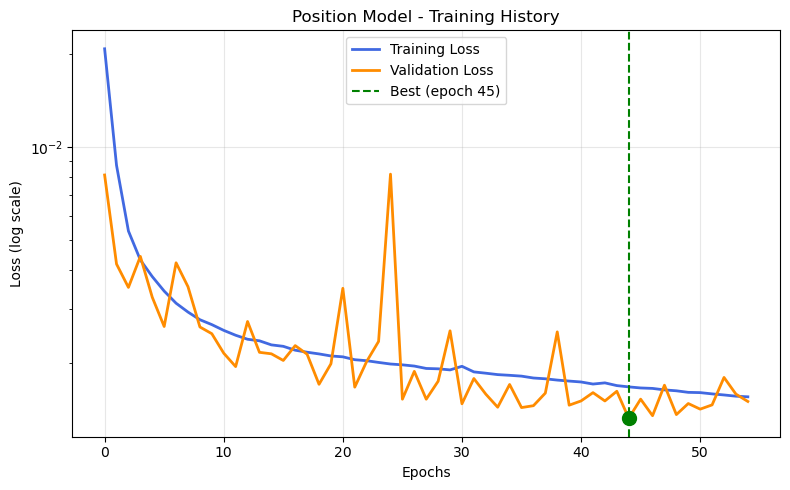

>> Position model: best epoch 45, val_loss=0.001324


In [9]:
# Plot POSITION training history
plt.figure(figsize=(8, 5))
best_epoch = np.argmin(pos_history.history['val_loss'])
best_val_loss = pos_history.history['val_loss'][best_epoch]

plt.plot(pos_history.history['loss'], label='Training Loss', color='royalblue', linewidth=2)
plt.plot(pos_history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2)
plt.axvline(x=best_epoch, color='green', linestyle='--', label=f'Best (epoch {best_epoch+1})')
plt.scatter([best_epoch], [best_val_loss], color='green', s=100, zorder=5)
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss (log scale)')
plt.title('Position Model - Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f">> Position model: best epoch {best_epoch+1}, val_loss={best_val_loss:.6f}")


In [10]:
# Export Position model for inference
import json
import gc

print(">> Exporting Position model for inference...")

# Convert numpy types to native Python types for JSON serialization
def convert_numpy_types(obj):
  if isinstance(obj, np.ndarray):
   return obj.tolist()
  elif isinstance(obj, (np.float32, np.float64)):
   return float(obj)
  elif isinstance(obj, (np.int32, np.int64)):
   return int(obj)
  elif isinstance(obj, dict):
   return {key: convert_numpy_types(value) for key, value in obj.items()}
  elif isinstance(obj, list):
   return [convert_numpy_types(item) for item in obj]
  return obj

# Base export path
from datetime import datetime
date_str = datetime.now().strftime('%m%d')
n_events = len(y_train)
n_str = f"{n_events//1000}k" if n_events >= 1000 else str(n_events)
base_export = f"/exp/sbnd/data/users/svidales/v{date_str}_trained_w_{n_str}"

# ========================================================================
# Export POSITION model
# ========================================================================
pos_export_path = base_export + "_position"
os.makedirs(pos_export_path, exist_ok=True)

pos_model_save_path = os.path.join(pos_export_path, 'saved_model')
PosModel.export(pos_model_save_path)
print(f"   * Position model exported to: {pos_export_path}")

>> Exporting Position model for inference...
INFO:tensorflow:Assets written to: /exp/sbnd/data/users/svidales/v0223_trained_w_177k_position/saved_model/assets


INFO:tensorflow:Assets written to: /exp/sbnd/data/users/svidales/v0223_trained_w_177k_position/saved_model/assets


Saved artifact at '/exp/sbnd/data/users/svidales/v0223_trained_w_177k_position/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 59, 70, 2), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140652686655184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140652686393408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140652686395696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140652686654832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140652686394112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140652686403616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140652686401152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140652686400096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140652686393760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140652686402384: TensorSpec(sha

### Direction Training

In [11]:
# =============================================================================
# TRAINING 2: DIRECTION MODEL (reduced ResNet-50, 2D YZ, sign-invariant angular loss)
# =============================================================================
print("=" * 60)
print("   TRAINING 2: DIRECTION MODEL (reduced ResNet-50, 2D YZ)")
print("=" * 60)

DIR_CONFIG = {
    'epochs': 150,
    'batch_size': 128,
    'patience': 10,
    'warmup_epochs': 5,      # épocas de warmup para el scheduler
    'min_lr': 1e-8,
    'dropout_rate': 0.3,
    'learning_rate': 1e-4,   # era 5e-4 → LR más conservador
}

print(f"   * Epochs: {DIR_CONFIG['epochs']}")
print(f"   * Batch size: {DIR_CONFIG['batch_size']}")
print(f"   * Patience: {DIR_CONFIG['patience']}")
print(f"   * LR: {DIR_CONFIG['learning_rate']}")
print(f"   * Loss: Angular loss (angle in radians, weighted by dEspread elongation)")
print(f"   * Dropout: {DIR_CONFIG['dropout_rate']}")

# Separate direction targets (2D: columns 3-4)
y_train_dir = y_train[:, 3:5]
y_val_dir = y_val[:, 3:5]
print(f"\n   * Train: {y_train_dir.shape}, Val: {y_val_dir.shape}")

# Extract directionality weights (column 5)
w_train_dir = y_train[:, 5]
w_val_dir   = y_val[:, 5]
print(f"   * Direction weights: train mean={np.mean(w_train_dir):.3f}, val mean={np.mean(w_val_dir):.3f}")

# Clean old checkpoint
dir_weights_file = '/tmp/weights_dir_model.keras'
if os.path.exists(dir_weights_file):
    os.remove(dir_weights_file)

# input_shape from training data (in case position model cell was not run)
input_shape = x_train.shape[1:]
print(f"   * Input shape: {input_shape}")

# Create direction model
DirModel = create_direction_model(input_shape, DIR_CONFIG['dropout_rate'])
print(f"   * Parameters: {DirModel.count_params():,}")

# Cosine decay con warmup (misma estrategia que el modelo de posición)
def cosine_decay_with_warmup_dir(epoch):
    warmup = DIR_CONFIG['warmup_epochs']
    total  = DIR_CONFIG['epochs']
    lr0    = DIR_CONFIG['learning_rate']
    min_lr = DIR_CONFIG['min_lr']
    if epoch < warmup:
        return lr0 * (epoch + 1) / warmup
    progress = (epoch - warmup) / max(total - warmup, 1)
    return min_lr + 0.5 * (lr0 - min_lr) * (1 + np.cos(np.pi * progress))

# Callbacks
dir_callbacks = [
    ModelCheckpoint(dir_weights_file, monitor='val_loss', verbose=1,
                    save_best_only=True, mode='min'),
    EarlyStopping(monitor='val_loss', patience=DIR_CONFIG['patience'],
                  restore_best_weights=True, verbose=1),
    LearningRateScheduler(cosine_decay_with_warmup_dir, verbose=0)
]

# Compile — angular_loss ya es robusta (acotada en [0, π/2]), no necesita Huber
# clipnorm evita gradientes explosivos
DirModel.compile(
    optimizer=Adam(learning_rate=DIR_CONFIG['learning_rate'], clipnorm=1.0),
    loss=angular_loss
)

# Train
print("\n>> Starting DIRECTION training...")
dir_history = DirModel.fit(
    x_train, y_train_dir,
    sample_weight=w_train_dir,
    epochs=DIR_CONFIG['epochs'],
    batch_size=DIR_CONFIG['batch_size'],
    callbacks=dir_callbacks,
    validation_data=(x_val, y_val_dir),
    verbose=1,
    shuffle=True
)

print("\n>> Direction training completed!")
best_epoch_dir = np.argmin(dir_history.history['val_loss'])
print(f"   * Best epoch: {best_epoch_dir + 1}")
print(f"   * Best val_loss: {dir_history.history['val_loss'][best_epoch_dir]:.6f} rad")
print(f"   * Best val_loss: {np.degrees(dir_history.history['val_loss'][best_epoch_dir]):.2f} deg")

   TRAINING 2: DIRECTION MODEL (reduced ResNet-50, 2D YZ)
   * Epochs: 150
   * Batch size: 128
   * Patience: 10
   * LR: 0.0001
   * Loss: Angular loss (angle in radians, weighted by dEspread elongation)
   * Dropout: 0.3

   * Train: (177437, 2), Val: (19716, 2)
   * Direction weights: train mean=1.000, val mean=0.996
   * Input shape: (59, 70, 2)
   * Parameters: 2,835,266

>> Starting DIRECTION training...
Epoch 1/150
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6538
Epoch 1: val_loss improved from None to 0.64546, saving model to /tmp/weights_dir_model.keras
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 47s 23ms/step - loss: 0.6395 - val_loss: 0.6455 - learning_rate: 2.0000e-05
Epoch 2/150
1384/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6280
Epoch 2: val_loss improved from 0.64546 to 0.63281, saving model to /tmp/weights_dir_model.keras
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 0.6248 - val_loss: 0.6328 - learning_rate: 4.0000e-05
Epoch 3/150
1387/1387 ━━━━━━━━━━━━━━━━

**Training loss vs epochs**

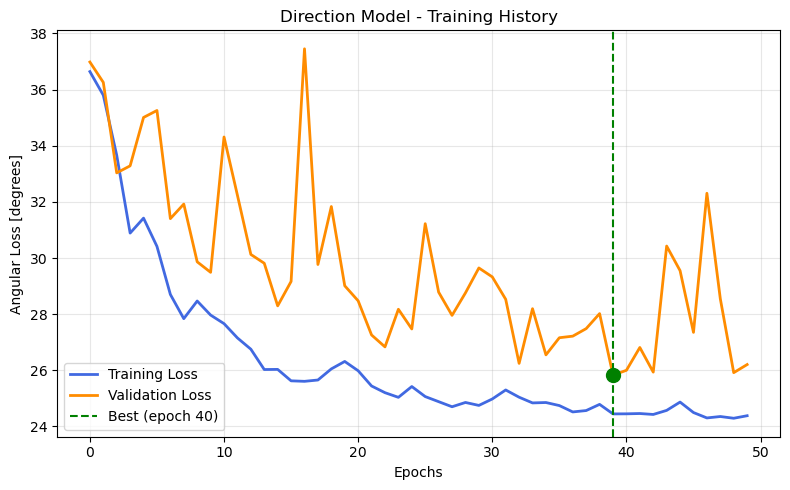

>> Direction model: best epoch 40, val_loss=25.83 deg


In [12]:
# Plot DIRECTION training history
plt.figure(figsize=(8, 5))
best_epoch_dir = np.argmin(dir_history.history['val_loss'])
best_val_loss_dir = dir_history.history['val_loss'][best_epoch_dir]

# Convertir a grados para el plot
train_loss_deg = np.degrees(dir_history.history['loss'])
val_loss_deg   = np.degrees(dir_history.history['val_loss'])

plt.plot(train_loss_deg, label='Training Loss', color='royalblue', linewidth=2)
plt.plot(val_loss_deg,   label='Validation Loss', color='darkorange', linewidth=2)
plt.axvline(x=best_epoch_dir, color='green', linestyle='--',
            label=f'Best (epoch {best_epoch_dir+1})')
plt.scatter([best_epoch_dir], [np.degrees(best_val_loss_dir)],
            color='green', s=100, zorder=5)
plt.xlabel('Epochs')
plt.ylabel('Angular Loss [degrees]')
plt.title('Direction Model - Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f">> Direction model: best epoch {best_epoch_dir+1}, val_loss={np.degrees(best_val_loss_dir):.2f} deg")

## 8. Model Export


In [13]:
# ========================================================================
# Export DIRECTION model
# ========================================================================
import json
from datetime import datetime
date_str = datetime.now().strftime('%m%d')
n_events = len(y_train)
n_str = f"{n_events//1000}k" if n_events >= 1000 else str(n_events)
base_export = f"/exp/sbnd/data/users/svidales/v{date_str}_trained_w_{n_str}"

dir_export_path = base_export + "_direction_2d"
os.makedirs(dir_export_path, exist_ok=True)

dir_model_save_path = os.path.join(dir_export_path, 'saved_model')
DirModel.export(dir_model_save_path)
print(f"   * Direction model exported to: {dir_export_path}")

# ========================================================================
# Save direction model config (metadata for inference)
# ========================================================================
inference_config = {
    'models': {
        'direction_2d': {
            'path': dir_model_save_path,
            'output': '2 (dirY, dirZ normalized, YZ plane)',
            'loss': 'angular_loss (atan2-based, sign-invariant)',
            'epochs_trained': len(dir_history.history['loss']),
            'best_val_loss_rad': float(min(dir_history.history['val_loss'])),
            'best_val_loss_deg': float(np.degrees(min(dir_history.history['val_loss']))),
        }
    },
    'training_events': len(y_train),
    'validation_events': len(y_val),
}

config_file = os.path.join(dir_export_path, 'inference_config.json')
with open(config_file, 'w') as f:
    json.dump(inference_config, f, indent=2)

print(f">> Export completed:")
print(f"   * Direction: {dir_export_path}")
print(f"   * Trained on {len(y_train):,} events")
print(f"   * Best val_loss: {min(dir_history.history['val_loss']):.4f} rad = {np.degrees(min(dir_history.history['val_loss'])):.2f} deg")


INFO:tensorflow:Assets written to: /exp/sbnd/data/users/svidales/v0224_trained_w_177k_direction_2d/saved_model/assets


INFO:tensorflow:Assets written to: /exp/sbnd/data/users/svidales/v0224_trained_w_177k_direction_2d/saved_model/assets


Saved artifact at '/exp/sbnd/data/users/svidales/v0224_trained_w_177k_direction_2d/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 59, 70, 2), dtype=tf.float32, name='keras_tensor_70')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  140650784509264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140639310146096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140639310147856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140639310147680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140639310144160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140639310146448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140636833281504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140636833274640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140636833277456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140636833283440: TensorS

## 9. Prediction


In [14]:

# ========================================================================
# Load saved models from disk (for inference without retraining)
# ========================================================================
import tensorflow as tf
import os

pos_model_path = '/exp/sbnd/data/users/svidales/v0223_trained_w_177k_position/saved_model'
dir_model_path = '/exp/sbnd/data/users/svidales/v0223_trained_w_177k_direction_2d/saved_model'

def _make_predict_fn(model_path):
    """Load a SavedModel and return a predict(x) -> np.ndarray function."""
    raw = tf.saved_model.load(model_path)
    infer = raw.signatures['serving_default']
    # Get the input/output key names from the signature
    input_key  = list(infer.structured_input_signature[1].keys())[0]
    output_key = list(infer.structured_outputs.keys())[0]
    def predict(x):
        x_tensor = tf.constant(x, dtype=tf.float32)
        result = infer(**{input_key: x_tensor})
        return result[output_key].numpy()
    return predict

# --- Position model ---
if os.path.exists(pos_model_path):
    _pos_predict_fn = _make_predict_fn(pos_model_path)
    class _PosWrapper:
        def predict(self, x): return _pos_predict_fn(x)
    PosModel = _PosWrapper()
    print(f">> Position model loaded from: {pos_model_path}")
    print(f"   * Input:  (N, 59, 70, 2)  |  Output: (N, 3) — (x, y, z scaled)")
else:
    print(f">> WARNING: position model not found at {pos_model_path}")
    print(f"   Using in-memory PosModel instead.")

# --- Direction model ---
if os.path.exists(dir_model_path):
    _dir_predict_fn = _make_predict_fn(dir_model_path)
    class _DirWrapper:
        def predict(self, x): return _dir_predict_fn(x)
    DirModel = _DirWrapper()
    print(f">> Direction model loaded from: {dir_model_path}")
    print(f"   * Input:  (N, 59, 70, 2)  |  Output: (N, 2) — (dirY, dirZ)")
else:
    print(f">> WARNING: direction model not found at {dir_model_path}")
    print(f"   Using in-memory DirModel instead.")


>> Position model loaded from: /exp/sbnd/data/users/svidales/v0223_trained_w_177k_position/saved_model
   * Input:  (N, 59, 70, 2)  |  Output: (N, 3) — (x, y, z scaled)
>> Direction model loaded from: /exp/sbnd/data/users/svidales/v0223_trained_w_177k_direction_2d/saved_model
   * Input:  (N, 59, 70, 2)  |  Output: (N, 2) — (dirY, dirZ)


## 10. Model Evaluation on Validation Set


>> Making predictions on validation set with both models...
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

>> Predictions completed for 19,716 validation events

   * POSITION errors (cm):
     - X: mean=0.59, std=11.10
     - Y: mean=-0.49, std=19.12
     - Z: mean=-0.97, std=24.58
     - 3D distance: mean=18.10 cm

   * DIRECTION 2D angular error (YZ plane, sign-invariant):
     - Mean:   25.83 deg
     - Median: 16.86 deg
     - Std:    24.37 deg
     - <10 deg: 36.1%
     - <20 deg: 54.7%
     - <45 deg: 78.3%


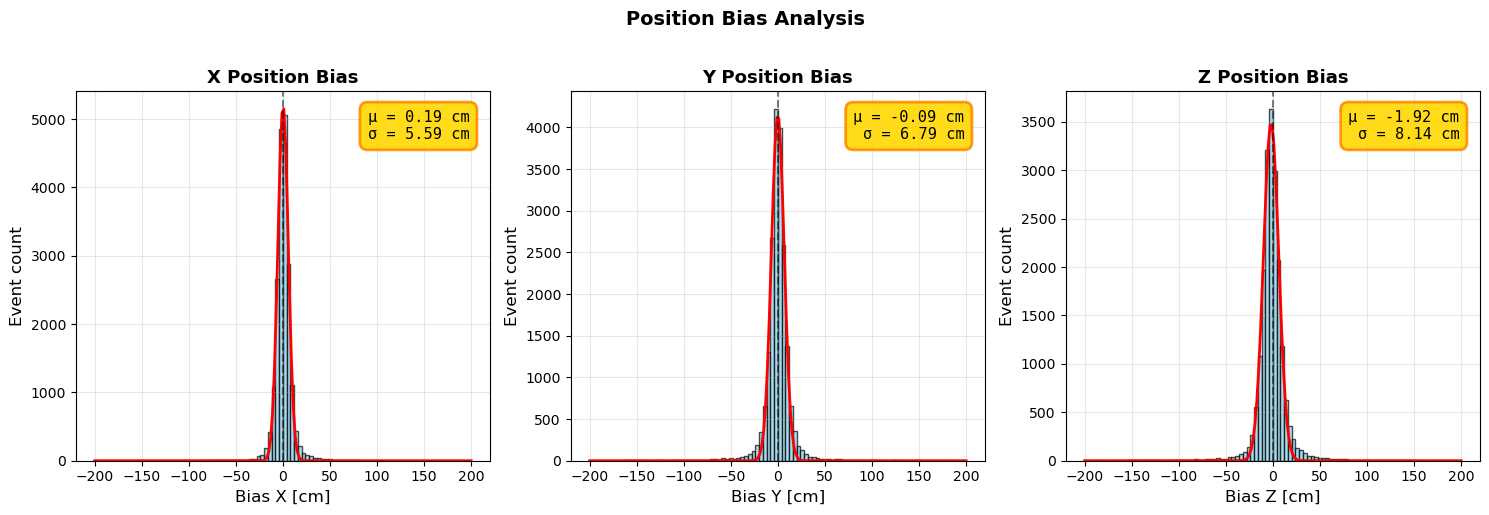

/tmp/ipykernel_603554/2679549246.py:110: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


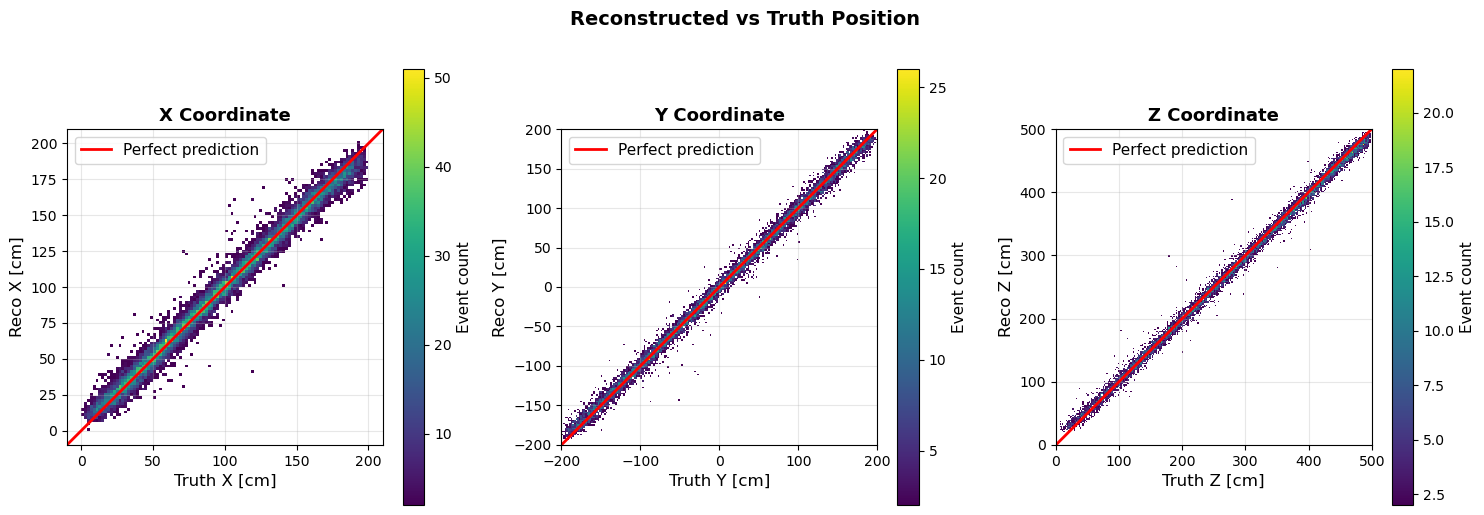

>> Performance Metrics:
   * RMSE per coordinate: X=11.11, Y=19.12, Z=24.60 cm
   * MAE per coordinate:  X=6.22, Y=9.04, Z=11.33 cm
   * Overall RMSE (3D):   19.10 cm


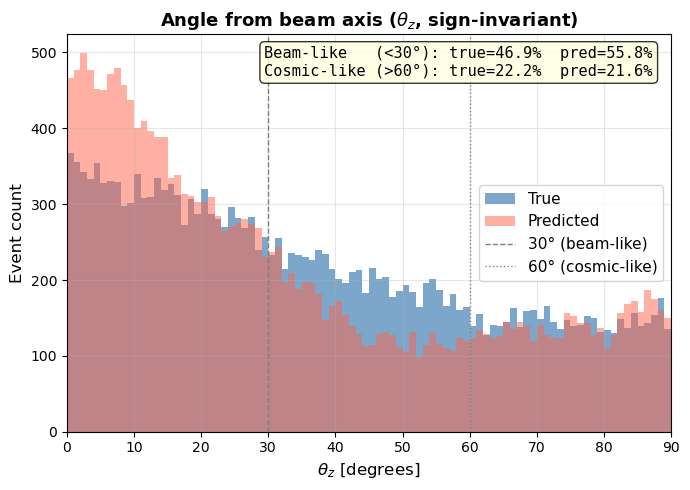

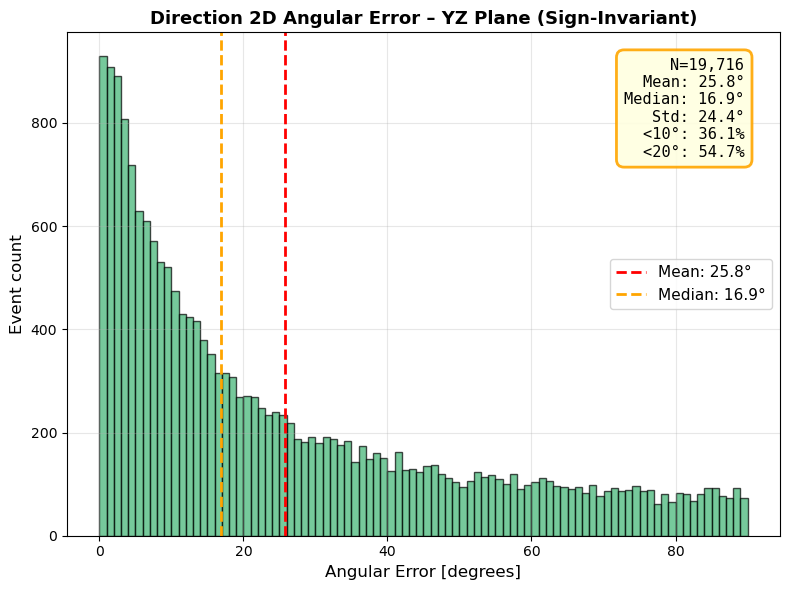


   RESULTS: TWO SEPARATE MODELS

>> POSITION (ResNet-18, MSE, original config):
   * X: bias=0.19 cm, sigma=5.59 cm
   * Y: bias=-0.09 cm, sigma=6.79 cm
   * Z: bias=-1.92 cm, sigma=8.14 cm

>> DIRECTION 2D YZ (ResNet-18, sign-invariant angular loss):
   * Mean: 25.83 deg, Median: 16.86 deg, Std: 24.37 deg
   * <10 deg: 36.1%, <20 deg: 54.7%


In [53]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def gaussian(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

# =============================================================================
# PREDICTIONS
# =============================================================================
print(">> Making predictions on validation set with both models...")

pos_pred_scaled  = PosModel.predict(x_val)
pos_val_scaled   = y_val[:, :3]
dir2d_pred_raw   = DirModel.predict(x_val)
dir2d_val_raw    = y_val[:, 3:5]

dir2d_pred = dir2d_pred_raw / (np.linalg.norm(dir2d_pred_raw, axis=1, keepdims=True) + 1e-8)
dir2d_val  = dir2d_val_raw  / (np.linalg.norm(dir2d_val_raw,  axis=1, keepdims=True) + 1e-8)

pos_pred_original = inverse_scale_coordinates(pos_pred_scaled, COORD_CONFIG['scale_ranges'])
pos_val_original  = inverse_scale_coordinates(pos_val_scaled,  COORD_CONFIG['scale_ranges'])

print(f"\n>> Predictions completed for {len(y_val):,} validation events")

pos_errors = pos_pred_original - pos_val_original
print(f"\n   * POSITION errors (cm):")
print(f"     - X: mean={np.mean(pos_errors[:, 0]):.2f}, std={np.std(pos_errors[:, 0]):.2f}")
print(f"     - Y: mean={np.mean(pos_errors[:, 1]):.2f}, std={np.std(pos_errors[:, 1]):.2f}")
print(f"     - Z: mean={np.mean(pos_errors[:, 2]):.2f}, std={np.std(pos_errors[:, 2]):.2f}")
print(f"     - 3D distance: mean={np.mean(np.linalg.norm(pos_errors, axis=1)):.2f} cm")

cross = dir2d_val[:, 0] * dir2d_pred[:, 1] - dir2d_val[:, 1] * dir2d_pred[:, 0]
dot   = np.sum(dir2d_val * dir2d_pred, axis=1)
angle_errors_2d_deg = np.degrees(np.arctan2(np.abs(cross), np.abs(dot)))

print(f"\n   * DIRECTION 2D angular error (YZ plane, sign-invariant):")
print(f"     - Mean:   {np.mean(angle_errors_2d_deg):.2f} deg")
print(f"     - Median: {np.median(angle_errors_2d_deg):.2f} deg")
print(f"     - Std:    {np.std(angle_errors_2d_deg):.2f} deg")
print(f"     - <10 deg: {100*np.mean(angle_errors_2d_deg < 10):.1f}%")
print(f"     - <20 deg: {100*np.mean(angle_errors_2d_deg < 20):.1f}%")
print(f"     - <45 deg: {100*np.mean(angle_errors_2d_deg < 45):.1f}%")

# =============================================================================
# POSITION BIAS ANALYSIS
# =============================================================================
diff_pos  = pos_pred_original - pos_val_original
pos_names = ['X', 'Y', 'Z']

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
bias_results_pos = {}

for i, coord in enumerate(pos_names):
    diff = diff_pos[:, i]
    counts, bins, _ = axs[i].hist(diff, bins=100, range=(-200, 200),
                                   alpha=0.7, color='skyblue', edgecolor='black')
    bin_centers = (bins[:-1] + bins[1:]) / 2
    try:
        popt, _ = curve_fit(gaussian, bin_centers, counts, p0=[np.max(counts), 0, 50], maxfev=5000)
        x_fit = np.linspace(-200, 200, 200)
        axs[i].plot(x_fit, gaussian(x_fit, *popt), 'r-', linewidth=2)
        bias_results_pos[coord] = {'mean': popt[1], 'sigma': abs(popt[2])}
    except:
        bias_results_pos[coord] = {'mean': np.mean(diff), 'sigma': np.std(diff)}

    axs[i].axvline(0, color='black', linestyle='--', alpha=0.5)
    axs[i].set_xlabel(f'Bias {coord} [cm]', fontsize=12)
    axs[i].set_ylabel('Event count', fontsize=12)
    axs[i].set_title(f'{coord} Position Bias', fontsize=13, fontweight='bold')
    axs[i].grid(True, alpha=0.3)
    m, s = bias_results_pos[coord]['mean'], bias_results_pos[coord]['sigma']
    axs[i].text(0.95, 0.95, f'\u03bc = {m:.2f} cm\n\u03c3 = {s:.2f} cm',
        transform=axs[i].transAxes, fontsize=11, va='top', ha='right', family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='gold', edgecolor='darkorange', linewidth=2, alpha=0.9))

plt.suptitle('Position Bias Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# RECONSTRUCTED VS TRUTH
# =============================================================================
coord_limits = [(-10, 210), (-200, 200), (0, 500)]
coord_bins   = [110, 200, 250]   # ~2 cm/bin

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, (coord, limits, nbins) in enumerate(zip(pos_names, coord_limits, coord_bins)):
    hist, xedges, yedges = np.histogram2d(
        pos_val_original[:, i],
        pos_pred_original[:, i],
        bins=nbins,
        range=[limits, limits]
    )
    hist_masked = np.ma.masked_where(hist <= 1, hist)
    im = axs[i].pcolormesh(xedges, yedges, hist_masked.T, cmap='viridis', shading='auto')
    cb = plt.colorbar(im, ax=axs[i])
    cb.set_label('Event count', fontsize=11)
    axs[i].plot(limits, limits, 'r-', linewidth=2, label='Perfect prediction')
    axs[i].set_xlim(limits)
    axs[i].set_ylim(limits)
    axs[i].set_xlabel(f'Truth {coord} [cm]', fontsize=12)
    axs[i].set_ylabel(f'Reco {coord} [cm]', fontsize=12)
    axs[i].set_title(f'{coord} Coordinate', fontsize=13, fontweight='bold')
    axs[i].grid(True, alpha=0.3)
    axs[i].set_aspect('equal')
    axs[i].legend(fontsize=11)

plt.suptitle('Reconstructed vs Truth Position', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

mse_per_coord  = np.mean((pos_pred_original - pos_val_original)**2, axis=0)
rmse_per_coord = np.sqrt(mse_per_coord)
mae_per_coord  = np.mean(np.abs(pos_pred_original - pos_val_original), axis=0)
overall_rmse   = np.sqrt(np.mean(rmse_per_coord**2))

print(f">> Performance Metrics:")
print(f"   * RMSE per coordinate: X={rmse_per_coord[0]:.2f}, Y={rmse_per_coord[1]:.2f}, Z={rmse_per_coord[2]:.2f} cm")
print(f"   * MAE per coordinate:  X={mae_per_coord[0]:.2f}, Y={mae_per_coord[1]:.2f}, Z={mae_per_coord[2]:.2f} cm")
print(f"   * Overall RMSE (3D):   {overall_rmse:.2f} cm")

# =============================================================================
# BEAM DIRECTION: Angle from beam axis
# =============================================================================
angle_from_beam_true = np.degrees(np.arccos(np.clip(dir2d_val[:, 1],          0, 1)))
angle_from_beam_pred = np.degrees(np.arccos(np.clip(np.abs(dir2d_pred[:, 1]), 0, 1)))

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.hist(angle_from_beam_true, bins=90, range=(0, 90),
        alpha=0.7, color='steelblue', edgecolor='none', label='True')
ax.hist(angle_from_beam_pred, bins=90, range=(0, 90),
        alpha=0.5, color='tomato',    edgecolor='none', label='Predicted')
ax.axvline(30, color='gray', linestyle='--', linewidth=1, label='30° (beam-like)')
ax.axvline(60, color='gray', linestyle=':',  linewidth=1, label='60° (cosmic-like)')
ax.set_xlabel(r'$\theta_z$ [degrees]', fontsize=12)
ax.set_ylabel('Event count', fontsize=12)
ax.set_title(r'Angle from beam axis ($\theta_z$, sign-invariant)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 90)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.text(0.97, 0.97,
    f'Beam-like   (<30°): true={100*np.mean(angle_from_beam_true < 30):.1f}%  pred={100*np.mean(angle_from_beam_pred < 30):.1f}%\n'
    f'Cosmic-like (>60°): true={100*np.mean(angle_from_beam_true > 60):.1f}%  pred={100*np.mean(angle_from_beam_pred > 60):.1f}%',
    transform=ax.transAxes, fontsize=11, va='top', ha='right', family='monospace',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.show()

# =============================================================================
# DIRECTION 2D ANGULAR ERROR
# =============================================================================
mean_angle   = np.mean(angle_errors_2d_deg)
median_angle = np.median(angle_errors_2d_deg)
std_angle    = np.std(angle_errors_2d_deg)
pct_10       = 100*np.mean(angle_errors_2d_deg < 10)
pct_20       = 100*np.mean(angle_errors_2d_deg < 20)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.hist(angle_errors_2d_deg, bins=90, range=(0, 90),
        alpha=0.7, color='mediumseagreen', edgecolor='black')
ax.axvline(mean_angle,   color='red',    linestyle='--', linewidth=2, label=f'Mean: {mean_angle:.1f}\u00b0')
ax.axvline(median_angle, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_angle:.1f}\u00b0')
ax.set_xlabel('Angular Error [degrees]', fontsize=12)
ax.set_ylabel('Event count', fontsize=12)
ax.set_title('Direction 2D Angular Error – YZ Plane (Sign-Invariant)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.text(0.95, 0.95,
    f'N={len(angle_errors_2d_deg):,}\nMean: {mean_angle:.1f}\u00b0\nMedian: {median_angle:.1f}\u00b0\nStd: {std_angle:.1f}\u00b0\n<10\u00b0: {pct_10:.1f}%\n<20\u00b0: {pct_20:.1f}%',
    transform=ax.transAxes, fontsize=11, va='top', ha='right', family='monospace',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor='orange', linewidth=2, alpha=0.9))
plt.tight_layout()
plt.show()

# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "="*60)
print("   RESULTS: TWO SEPARATE MODELS")
print("="*60)
print("\n>> POSITION (ResNet-18, MSE, original config):")
for coord in pos_names:
    m, s = bias_results_pos[coord]['mean'], bias_results_pos[coord]['sigma']
    print(f"   * {coord}: bias={m:.2f} cm, sigma={s:.2f} cm")
print(f"\n>> DIRECTION 2D YZ (ResNet-18, sign-invariant angular loss):")
print(f"   * Mean: {mean_angle:.2f} deg, Median: {median_angle:.2f} deg, Std: {std_angle:.2f} deg")
print(f"   * <10 deg: {pct_10:.1f}%, <20 deg: {pct_20:.1f}%")
print("="*60)


## 11. Model Evaluation on Test Set


In [54]:
# ============================================================================
# TEST SET EVALUATION
# ============================================================================

# Load preprocessed TEST NPZ files
import glob

preprocessed_dir = '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/preprocessed_images/resnet18_onetpc_withPCA/test'

# Find all test files
test_npz_files = sorted(glob.glob(os.path.join(preprocessed_dir, 'test_fall_prod_v0902_withPCA_part*.npz')))
print(f">> Found {len(test_npz_files)} preprocessed TEST files:")
for f in test_npz_files:
    print(f"   * {os.path.basename(f)}")

# Load and combine all test files
all_images_test = []
all_x_abs_test  = []
all_y_test      = []
all_z_test      = []

for npz_file in test_npz_files:
    print(f"\n>> Loading {os.path.basename(npz_file)}...")
    data = np.load(npz_file)

    all_images_test.append(data['images'])
    all_x_abs_test.append(data['dEpromx_abs'])
    all_y_test.append(data['dEpromy'])
    all_z_test.append(data['dEpromz'])

    print(f"   * Events: {len(data['images']):,}")

# Combine all test data
print("\n>> Combining all test files...")
images_test_raw = np.concatenate(all_images_test, axis=0)
x_abs_test      = np.concatenate(all_x_abs_test,  axis=0)
y_coord_test    = np.concatenate(all_y_test,       axis=0)
z_coord_test    = np.concatenate(all_z_test,       axis=0)

# Normalize using SAME global_max from training
print(f"\n>> Normalizing test images using training global_max...")
print(f"   * Using normalization_factor from training: {normalization_factor:.1f}")
images_test = images_test_raw / normalization_factor

# Summary
print(f"\n>> Test data loaded and normalized:")
print(f"   * Total test events: {len(images_test):,}")
print(f"   * Images shape: {images_test.shape}")
print(f"   * Images range: [{images_test.min():.6f}, {images_test.max():.6f}]")

# Clean up
del images_test_raw, all_images_test, all_x_abs_test, all_y_test, all_z_test
gc.collect()
print("\n>> Memory cleaned up")

>> Found 2 preprocessed TEST files:
   * test_fall_prod_v0902_withPCA_part01.npz
   * test_fall_prod_v0902_withPCA_part02.npz

>> Loading test_fall_prod_v0902_withPCA_part01.npz...
   * Events: 24,727

>> Loading test_fall_prod_v0902_withPCA_part02.npz...
   * Events: 24,956

>> Combining all test files...

>> Normalizing test images using training global_max...
   * Using normalization_factor from training: 210603.0

>> Test data loaded and normalized:
   * Total test events: 49,683
   * Images shape: (49683, 59, 70, 2)
   * Images range: [-0.000000, 0.597537]

>> Memory cleaned up


>> Loading direction data from test NPZ files...


   * Sign-flipped 24,634 events (49.6%) to enforce dz >= 0
   * Filtering 118 degenerate events from test set
   * Test events after filtering: 49,565

>> Making predictions on test set...
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
   * Predictions completed for 49,565 test events

   * POSITION errors (cm):
     - X: mean=0.51, std=10.93
     - Y: mean=-0.46, std=18.92
     - Z: mean=-1.36, std=24.56

   * DIRECTION angular error:
     - Mean: 25.92 deg, Median: 16.76 deg


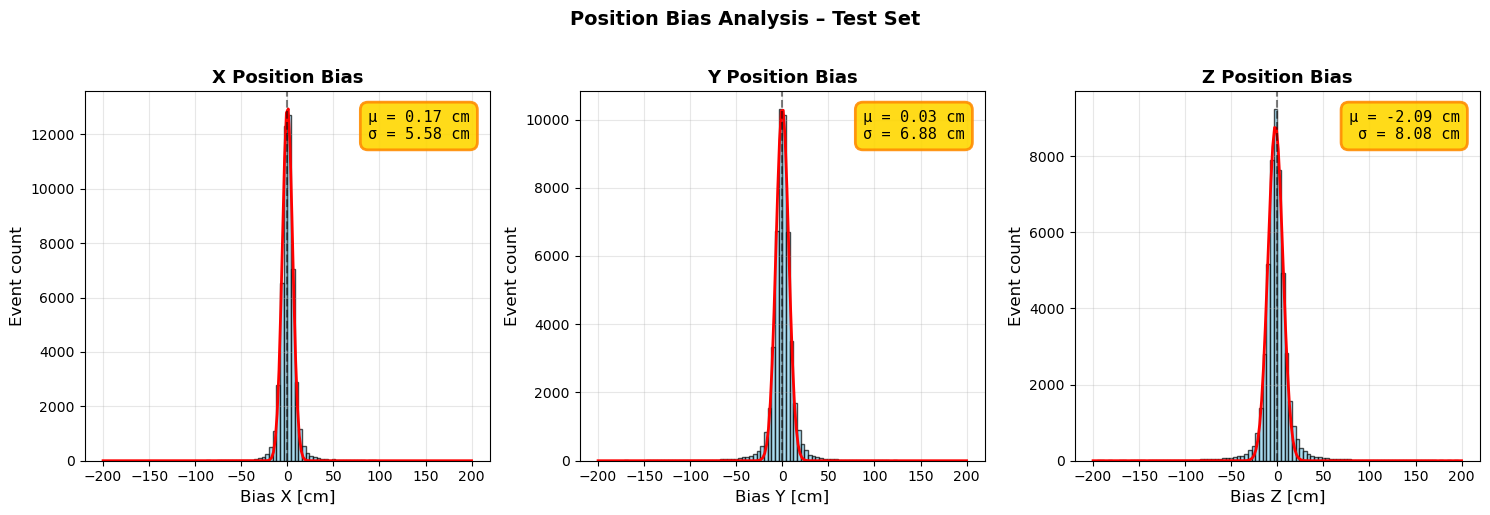

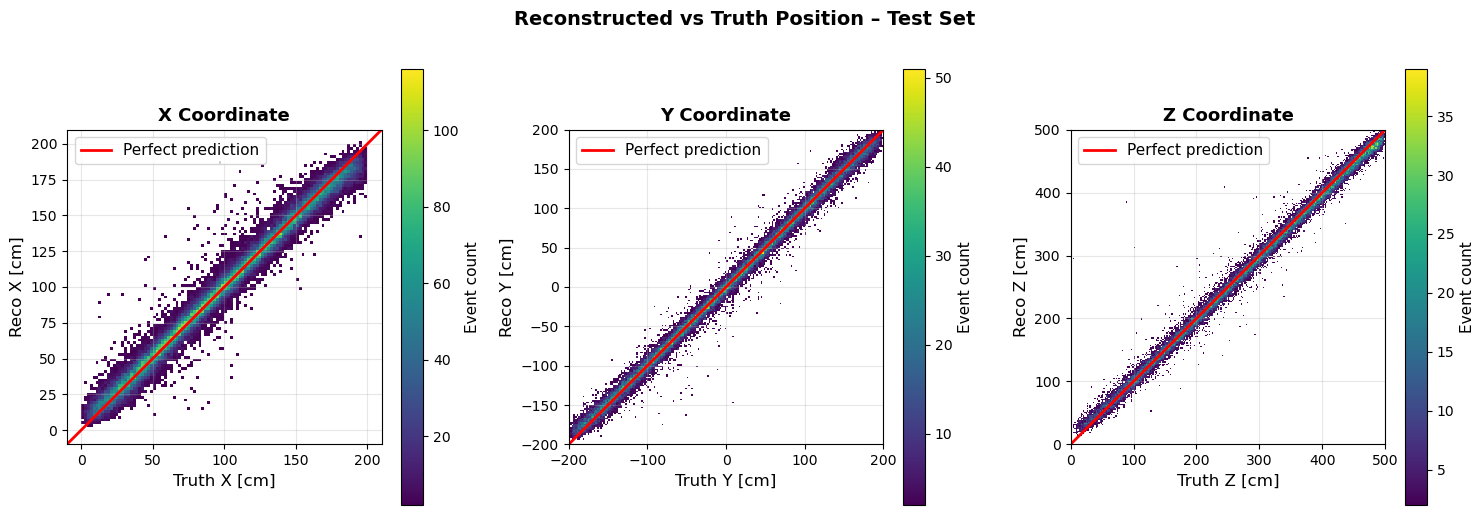

>> Performance Metrics (Test Set):
   * RMSE: X=10.94, Y=18.92, Z=24.60 cm
   * MAE:  X=6.19, Y=9.03, Z=11.34 cm
   * Overall RMSE (3D): 19.00 cm


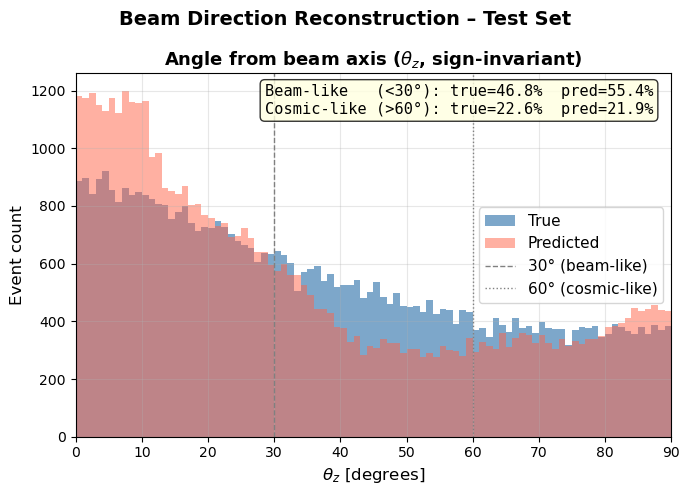

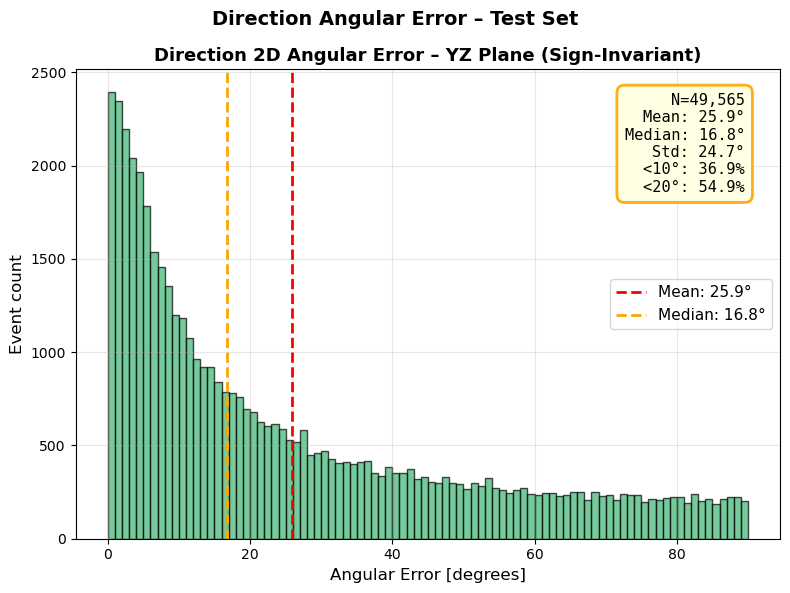

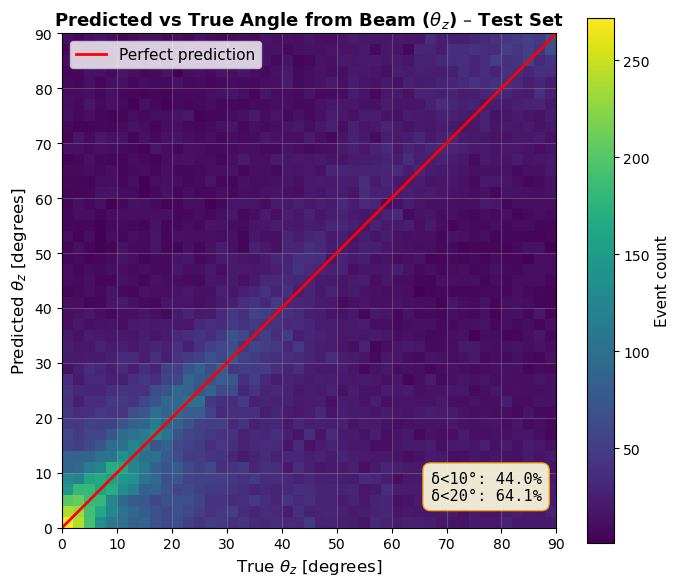


   RESULTS: TEST SET

>> POSITION:
   * X: bias=0.17 cm, sigma=5.58 cm
   * Y: bias=0.03 cm, sigma=6.88 cm
   * Z: bias=-2.09 cm, sigma=8.08 cm

>> DIRECTION 2D YZ (sign-invariant angular loss):
   * Mean: 25.92 deg, Median: 16.76 deg, Std: 24.67 deg
   * <10 deg: 36.9%, <20 deg: 54.9%


In [68]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def gaussian(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

# =============================================================================
# LOAD DIRECTION DATA + BUILD FULL TEST DATASET
# =============================================================================
print(">> Loading direction data from test NPZ files...")

all_diry_test = []
all_dirz_test = []
all_x_abs_test2 = []
all_y_test2     = []
all_z_test2     = []
all_images2     = []

for npz_file in test_npz_files:
    data = np.load(npz_file)
    all_images2.append(data['images'])
    all_x_abs_test2.append(data['dEpromx_abs'])
    all_y_test2.append(data['dEpromy'])
    all_z_test2.append(data['dEpromz'])
    all_diry_test.append(data['dEdiry'])
    all_dirz_test.append(data['dEdirz'])

images_test_raw2 = np.concatenate(all_images2,     axis=0)
x_abs_t  = np.concatenate(all_x_abs_test2,         axis=0)
y_t      = np.concatenate(all_y_test2,              axis=0)
z_t      = np.concatenate(all_z_test2,              axis=0)
diry_t   = np.concatenate(all_diry_test,            axis=0)
dirz_t   = np.concatenate(all_dirz_test,            axis=0)
del all_images2, all_x_abs_test2, all_y_test2, all_z_test2, all_diry_test, all_dirz_test

# Enforce dz >= 0 convention (same as training/validation NPZ)
flip_mask      = dirz_t < 0
diry_t[flip_mask] *= -1
dirz_t[flip_mask] *= -1
print(f"   * Sign-flipped {np.sum(flip_mask):,} events ({100*np.mean(flip_mask):.1f}%) to enforce dz >= 0")

# Scale position coordinates (same as training)
coordinates_t = np.column_stack((x_abs_t, y_t, z_t))
pos_scaled_t  = scale_coordinates(coordinates_t, COORD_CONFIG['scale_ranges'])

# Project direction onto YZ plane and normalize
norm_yz_t      = np.sqrt(diry_t**2 + dirz_t**2)
norm_yz_safe_t = np.maximum(norm_yz_t, 1e-6)
dir2d_y_t      = diry_t / norm_yz_safe_t
dir2d_z_t      = dirz_t / norm_yz_safe_t

# Filter degenerate events
good_t = norm_yz_t >= 0.1
n_removed_t = np.sum(~good_t)
if n_removed_t > 0:
    print(f"   * Filtering {n_removed_t} degenerate events from test set")
    pos_scaled_t   = pos_scaled_t[good_t]
    dir2d_y_t      = dir2d_y_t[good_t]
    dir2d_z_t      = dir2d_z_t[good_t]
    images_test_raw2 = images_test_raw2[good_t]

# Normalize images
x_test = images_test_raw2 / normalization_factor
del images_test_raw2
gc.collect()

# Build combined label array  [pos(3), dir2d(2)]
y_test_full = np.column_stack((pos_scaled_t, dir2d_y_t, dir2d_z_t))
print(f"   * Test events after filtering: {len(x_test):,}")

# =============================================================================
# PREDICTIONS ON TEST SET
# =============================================================================
print("\n>> Making predictions on test set...")

pos_pred_scaled_t  = PosModel.predict(x_test)
dir2d_pred_raw_t   = DirModel.predict(x_test)

# Normalize direction predictions to unit vectors
dir2d_pred_t = dir2d_pred_raw_t / (np.linalg.norm(dir2d_pred_raw_t, axis=1, keepdims=True) + 1e-8)
dir2d_val_t  = y_test_full[:, 3:5] / (np.linalg.norm(y_test_full[:, 3:5], axis=1, keepdims=True) + 1e-8)

# Inverse scale position predictions
pos_pred_test  = inverse_scale_coordinates(pos_pred_scaled_t,     COORD_CONFIG['scale_ranges'])
pos_true_test  = inverse_scale_coordinates(y_test_full[:, :3],    COORD_CONFIG['scale_ranges'])

print(f"   * Predictions completed for {len(x_test):,} test events")

# Angular error
cross_t = dir2d_val_t[:, 0] * dir2d_pred_t[:, 1] - dir2d_val_t[:, 1] * dir2d_pred_t[:, 0]
dot_t   = np.sum(dir2d_val_t * dir2d_pred_t, axis=1)
angle_errors_test_deg = np.degrees(np.arctan2(np.abs(cross_t), np.abs(dot_t)))

pos_errors_t = pos_pred_test - pos_true_test
print(f"\n   * POSITION errors (cm):")
print(f"     - X: mean={np.mean(pos_errors_t[:, 0]):.2f}, std={np.std(pos_errors_t[:, 0]):.2f}")
print(f"     - Y: mean={np.mean(pos_errors_t[:, 1]):.2f}, std={np.std(pos_errors_t[:, 1]):.2f}")
print(f"     - Z: mean={np.mean(pos_errors_t[:, 2]):.2f}, std={np.std(pos_errors_t[:, 2]):.2f}")
print(f"\n   * DIRECTION angular error:")
print(f"     - Mean: {np.mean(angle_errors_test_deg):.2f} deg, Median: {np.median(angle_errors_test_deg):.2f} deg")

# =============================================================================
# POSITION BIAS ANALYSIS
# =============================================================================
pos_names = ['X', 'Y', 'Z']
diff_pos_t = pos_pred_test - pos_true_test

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
bias_results_test = {}

for i, coord in enumerate(pos_names):
    diff = diff_pos_t[:, i]
    counts, bins, _ = axs[i].hist(diff, bins=100, range=(-200, 200),
                                   alpha=0.7, color='skyblue', edgecolor='black')
    bin_centers = (bins[:-1] + bins[1:]) / 2
    try:
        popt, _ = curve_fit(gaussian, bin_centers, counts, p0=[np.max(counts), 0, 50], maxfev=5000)
        x_fit = np.linspace(-200, 200, 200)
        axs[i].plot(x_fit, gaussian(x_fit, *popt), 'r-', linewidth=2)
        bias_results_test[coord] = {'mean': popt[1], 'sigma': abs(popt[2])}
    except:
        bias_results_test[coord] = {'mean': np.mean(diff), 'sigma': np.std(diff)}

    axs[i].axvline(0, color='black', linestyle='--', alpha=0.5)
    axs[i].set_xlabel(f'Bias {coord} [cm]', fontsize=12)
    axs[i].set_ylabel('Event count', fontsize=12)
    axs[i].set_title(f'{coord} Position Bias', fontsize=13, fontweight='bold')
    axs[i].grid(True, alpha=0.3)
    m, s = bias_results_test[coord]['mean'], bias_results_test[coord]['sigma']
    axs[i].text(0.95, 0.95, f'\u03bc = {m:.2f} cm\n\u03c3 = {s:.2f} cm',
        transform=axs[i].transAxes, fontsize=11, va='top', ha='right', family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='gold', edgecolor='darkorange', linewidth=2, alpha=0.9))

plt.suptitle('Position Bias Analysis – Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# RECONSTRUCTED VS TRUTH
# =============================================================================
coord_limits = [(-10, 210), (-200, 200), (0, 500)]
coord_bins   = [110, 200, 250]

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, (coord, limits, nbins) in enumerate(zip(pos_names, coord_limits, coord_bins)):
    hist, xedges, yedges = np.histogram2d(
        pos_true_test[:, i], pos_pred_test[:, i],
        bins=nbins, range=[limits, limits]
    )
    hist_masked = np.ma.masked_where(hist <= 1, hist)
    im = axs[i].pcolormesh(xedges, yedges, hist_masked.T, cmap='viridis', shading='auto')
    cb = plt.colorbar(im, ax=axs[i])
    cb.set_label('Event count', fontsize=11)
    axs[i].plot(limits, limits, 'r-', linewidth=2, label='Perfect prediction')
    axs[i].set_xlim(limits)
    axs[i].set_ylim(limits)
    axs[i].set_xlabel(f'Truth {coord} [cm]', fontsize=12)
    axs[i].set_ylabel(f'Reco {coord} [cm]', fontsize=12)
    axs[i].set_title(f'{coord} Coordinate', fontsize=13, fontweight='bold')
    axs[i].grid(True, alpha=0.3)
    axs[i].set_aspect('equal')
    axs[i].legend(fontsize=11)

plt.suptitle('Reconstructed vs Truth Position – Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

mse_t  = np.mean((pos_pred_test - pos_true_test)**2, axis=0)
rmse_t = np.sqrt(mse_t)
mae_t  = np.mean(np.abs(pos_pred_test - pos_true_test), axis=0)
print(f">> Performance Metrics (Test Set):")
print(f"   * RMSE: X={rmse_t[0]:.2f}, Y={rmse_t[1]:.2f}, Z={rmse_t[2]:.2f} cm")
print(f"   * MAE:  X={mae_t[0]:.2f}, Y={mae_t[1]:.2f}, Z={mae_t[2]:.2f} cm")
print(f"   * Overall RMSE (3D): {np.sqrt(np.mean(rmse_t**2)):.2f} cm")

# =============================================================================
# BEAM DIRECTION: Angle from beam axis
# =============================================================================
angle_from_beam_true_t = np.degrees(np.arccos(np.clip(dir2d_val_t[:, 1],          0, 1)))
angle_from_beam_pred_t = np.degrees(np.arccos(np.clip(np.abs(dir2d_pred_t[:, 1]), 0, 1)))

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.hist(angle_from_beam_true_t, bins=90, range=(0, 90),
        alpha=0.7, color='steelblue', edgecolor='none', label='True')
ax.hist(angle_from_beam_pred_t, bins=90, range=(0, 90),
        alpha=0.5, color='tomato',    edgecolor='none', label='Predicted')
ax.axvline(30, color='gray', linestyle='--', linewidth=1, label='30° (beam-like)')
ax.axvline(60, color='gray', linestyle=':',  linewidth=1, label='60° (cosmic-like)')
ax.set_xlabel(r'$\theta_z$ [degrees]', fontsize=12)
ax.set_ylabel('Event count', fontsize=12)
ax.set_title(r'Angle from beam axis ($\theta_z$, sign-invariant)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 90)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.text(0.97, 0.97,
    f'Beam-like   (<30°): true={100*np.mean(angle_from_beam_true_t < 30):.1f}%  pred={100*np.mean(angle_from_beam_pred_t < 30):.1f}%\n'
    f'Cosmic-like (>60°): true={100*np.mean(angle_from_beam_true_t > 60):.1f}%  pred={100*np.mean(angle_from_beam_pred_t > 60):.1f}%',
    transform=ax.transAxes, fontsize=11, va='top', ha='right', family='monospace',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.suptitle('Beam Direction Reconstruction – Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================================================
# DIRECTION 2D ANGULAR ERROR
# =============================================================================
mean_angle_t   = np.mean(angle_errors_test_deg)
median_angle_t = np.median(angle_errors_test_deg)
std_angle_t    = np.std(angle_errors_test_deg)
pct_10_t       = 100*np.mean(angle_errors_test_deg < 10)
pct_20_t       = 100*np.mean(angle_errors_test_deg < 20)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.hist(angle_errors_test_deg, bins=90, range=(0, 90),
        alpha=0.7, color='mediumseagreen', edgecolor='black')
ax.axvline(mean_angle_t,   color='red',    linestyle='--', linewidth=2, label=f'Mean: {mean_angle_t:.1f}\u00b0')
ax.axvline(median_angle_t, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_angle_t:.1f}\u00b0')
ax.set_xlabel('Angular Error [degrees]', fontsize=12)
ax.set_ylabel('Event count', fontsize=12)
ax.set_title('Direction 2D Angular Error – YZ Plane (Sign-Invariant)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.text(0.95, 0.95,
    f'N={len(angle_errors_test_deg):,}\nMean: {mean_angle_t:.1f}\u00b0\nMedian: {median_angle_t:.1f}\u00b0\nStd: {std_angle_t:.1f}\u00b0\n<10\u00b0: {pct_10_t:.1f}%\n<20\u00b0: {pct_20_t:.1f}%',
    transform=ax.transAxes, fontsize=11, va='top', ha='right', family='monospace',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor='orange', linewidth=2, alpha=0.9))
plt.suptitle('Direction Angular Error – Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# =============================================================================
# PREDICTED vs TRUE ANGLE FROM BEAM
# =============================================================================
angle_range = (0, 90)
angle_bins  = 45   # 2 deg/bin

hist_ang, xedges_ang, yedges_ang = np.histogram2d(
    angle_from_beam_true_t, angle_from_beam_pred_t,
    bins=angle_bins, range=[angle_range, angle_range]
)
hist_ang_masked = np.ma.masked_where(hist_ang == 0, hist_ang)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
im = ax.pcolormesh(xedges_ang, yedges_ang, hist_ang_masked.T,
                   cmap='viridis', shading='auto')
cb = plt.colorbar(im, ax=ax)
cb.set_label('Event count', fontsize=11)
ax.plot(angle_range, angle_range, 'r-', linewidth=2, label='Perfect prediction')
ax.set_xlim(angle_range)
ax.set_ylim(angle_range)
ax.set_xlabel(r'True $\theta_z$ [degrees]', fontsize=12)
ax.set_ylabel(r'Predicted $\theta_z$ [degrees]', fontsize=12)
ax.set_title(r'Predicted vs True Angle from Beam ($\theta_z$) – Test Set',
             fontsize=13, fontweight='bold')
ax.set_aspect('equal')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

within_10 = 100 * np.mean(np.abs(angle_from_beam_pred_t - angle_from_beam_true_t) < 10)
within_20 = 100 * np.mean(np.abs(angle_from_beam_pred_t - angle_from_beam_true_t) < 20)
ax.text(0.97, 0.05,
    f'\u03b4<10\u00b0: {within_10:.1f}%\n\u03b4<20\u00b0: {within_20:.1f}%',
    transform=ax.transAxes, fontsize=11, va='bottom', ha='right', family='monospace',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor='orange', alpha=0.9))

plt.tight_layout()
plt.show()

# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "="*60)
print("   RESULTS: TEST SET")
print("="*60)
print("\n>> POSITION:")
for coord in pos_names:
    m, s = bias_results_test[coord]['mean'], bias_results_test[coord]['sigma']
    print(f"   * {coord}: bias={m:.2f} cm, sigma={s:.2f} cm")
print(f"\n>> DIRECTION 2D YZ (sign-invariant angular loss):")
print(f"   * Mean: {mean_angle_t:.2f} deg, Median: {median_angle_t:.2f} deg, Std: {std_angle_t:.2f} deg")
print(f"   * <10 deg: {pct_10_t:.1f}%, <20 deg: {pct_20_t:.1f}%")
print("="*60)


## 12. Training Summary


In [59]:
print("=" * 60)
print("   TRAINING PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 60)

print(f"\n>> Dataset:")
print(f"   * Training events:   {len(y_train):,}")
print(f"   * Validation events: {len(y_val):,}")

print(f"\n>> Models saved:")
print(f"   * Position:  {pos_model_save_path}")
print(f"   * Direction: {dir_model_save_path}")

print(f"\n>> Validation performance:")
print(f"   * Final val loss (pos): {min(pos_history.history['val_loss']):.6f}")
print(f"   * Overall RMSE (3D):    {overall_rmse:.2f} cm")
for coord in pos_names:
    mean  = bias_results_pos[coord]['mean']
    sigma = bias_results_pos[coord]['sigma']
    print(f"   * {coord}: bias = {mean:.2f} cm,  sigma = {sigma:.2f} cm")

print(f"\n>> Test performance:")
print(f"   * Overall RMSE (3D): {np.sqrt(np.mean(rmse_t**2)):.2f} cm")
for coord in pos_names:
    mean  = bias_results_test[coord]['mean']
    sigma = bias_results_test[coord]['sigma']
    print(f"   * {coord}: bias = {mean:.2f} cm,  sigma = {sigma:.2f} cm")

print(f"\n>> Direction (YZ plane, sign-invariant):")
print(f"   * Validation — mean: {mean_angle:.2f}°,  median: {median_angle:.2f}°")
print(f"   * Test        — mean: {mean_angle_t:.2f}°,  median: {median_angle_t:.2f}°")

# Clean up memory
for var in ['x_train', 'x_val', 'y_train', 'y_val', 'images', 'pe_matrix']:
    if var in dir():
        del var
gc.collect()
print(f"\n>> Memory cleaned up")
print("=" * 60)


   TRAINING PIPELINE COMPLETED SUCCESSFULLY

>> Dataset:
   * Training events:   177,437
   * Validation events: 19,716

>> Models saved:
   * Position:  /exp/sbnd/data/users/svidales/v0223_trained_w_177k_position/saved_model
   * Direction: /exp/sbnd/data/users/svidales/v0224_trained_w_177k_direction_2d/saved_model

>> Validation performance:
   * Final val loss (pos): 0.001324
   * Overall RMSE (3D):    19.10 cm
   * X: bias = 0.19 cm,  sigma = 5.59 cm
   * Y: bias = -0.09 cm,  sigma = 6.79 cm
   * Z: bias = -1.92 cm,  sigma = 8.14 cm

>> Test performance:
   * Overall RMSE (3D): 19.00 cm
   * X: bias = 0.17 cm,  sigma = 5.58 cm
   * Y: bias = 0.03 cm,  sigma = 6.88 cm
   * Z: bias = -2.09 cm,  sigma = 8.08 cm

>> Direction (YZ plane, sign-invariant):
   * Validation — mean: 25.83°,  median: 16.86°
   * Test        — mean: 25.92°,  median: 16.76°

>> Memory cleaned up
